## Artificial Neural Networks and Deep Learning
#### Challenge 2 - Year 2025/2026
#### Team: Va Alianza Toca la U

*   Luis Caballero Fritas
*   Camilo Martínez Mejía
*   Daffer Queque Palomino
*   Reinaldo Toledo Leguizamón


Notebook: Exploration Data Analysis






## ⚙️ **Libraries Import**

In [ ]:
!pip install torchview tb-nightly timm umap-learn==0.5.1 --quiet
#!pip install staintools --quiet

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# for kaggle
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import pandas as pd
from PIL import Image


# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import InterpolationMode
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import requests
from io import BytesIO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

E0000 00:00:1765398681.727187    4446 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765398681.734314    4446 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

PyTorch version: 2.6.0+cu124
Device: cuda


## ⏳ **Data Loading**

In [ ]:
# import staintools

# # Fit once on a reference image
# ref_img = staintools.read_image("reference_image.png")
# normalizer = staintools.StainNormalizer(method='macenko')
# normalizer.fit(ref_img)  # learn reference stain

# # In __getitem__, after cropping:
# img_np = np.array(img)  # PIL -> numpy
# img_normalized = normalizer.transform(img_np)
# img = Image.fromarray(img_normalized)


In [ ]:
def crop_to_mask(image, mask, pad=16):
    """
    Crops the image to the bounding box of the mask.
    image, mask: PIL images
    """
    mask_np = np.array(mask)
    ys, xs = np.where(mask_np > 0)

    if len(xs) == 0 or len(ys) == 0:
        # fallback: return full image
        return image

    x1, y1 = xs.min(), ys.min()
    x2, y2 = xs.max(), ys.max()

    # Add padding
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(image.width,  x2 + pad)
    y2 = min(image.height, y2 + pad)

    return image.crop((x1, y1, x2, y2))


class HistopathDataset(Dataset):
    """
    Kaggle histopathology dataset loader.
    Supports three modes:
      - 'image': use only the RGB image
      - 'crop': crop image to mask bounding box
      - 'image+mask': return 4-channel tensor (RGB + mask)
    """

    def __init__(self, df, root,
                 mode="crop",
                 transform=None,
                 pad=16):

        assert mode in ["image", "crop", "image+mask"], \
               "mode must be one of: 'image', 'crop', 'image+mask'"

        self.df = df.copy()
        # Filter the DF to include ONLY image files
        self.df = self.df[self.df["sample_index"].str.startswith("img_")].reset_index(drop=True)
        self.root = root
        self.mode = mode
        self.transform = transform
        self.pad = pad

        # class label mapping
        self.class_to_idx = {
            "Luminal A": 0,
            "Luminal B": 1,
            "HER2(+)": 2,
            "Triple negative": 3
        }


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row["sample_index"]
        mask_id = img_id.replace("img_", "mask_")

        img_path  = os.path.join(self.root, img_id)
        mask_path = os.path.join(self.root, mask_id)

        # load PIL
        img  = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize mask only if sizes mismatch
        if img.size != mask.size:
            print(f"Resizing {mask_id} from {mask.size} to {img.size}")
            mask = mask.resize(img.size, resample=Image.NEAREST)

        # ---- MODE: CROP -----------------------------------------------------
        if self.mode == "crop":
            img = crop_to_mask(img, mask, pad=self.pad)

        # ---- MODE: IMAGE+MASK (stack mask as 4th channel) -------------------
        if self.mode == "image+mask":
            img.putalpha(mask)  # img now has RGBA

        if self.transform:
            img = self.transform(img)

        # labels if training
        if "label" in row:
            return img, self.class_to_idx[row["label"]]
        return img


In [ ]:
def fill_histopath_dataset(dataset, img_size=128, batch_size=64, use_mask=False):
    """
    Load a HistopathDataset into pre-allocated tensors for fast exploration.

    Args:
        dataset: instance of HistopathDataset
        batch_size: batch size for DataLoader
        use_mask: if True, dataset must be in 'image+mask' mode (4 channels)

    Returns:
        X: Tensor of shape (N, C, H, W)
        y: Tensor of shape (N,)
    """
    n_samples = len(dataset)
    # Determine channels
    channels = 4 if use_mask else 3
    img_size = img_size # predefined for visualization

    # Pre-allocate tensors
    X = torch.zeros((n_samples, channels, img_size, img_size), dtype=torch.float32)
    y = torch.zeros(n_samples, dtype=torch.int64)

    # DataLoader for batch loading
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=os.cpu_count() or 2, pin_memory=True)

    print(f"Loading {n_samples} images with {loader.num_workers} workers...")

    start_idx = 0
    for batch in loader:
        if isinstance(batch, (list, tuple)):
            batch_x, batch_y = batch
        else:
            batch_x, batch_y = batch, None

        end_idx = start_idx + batch_x.shape[0]
        X[start_idx:end_idx] = batch_x
        if batch_y is not None:
            y[start_idx:end_idx] = batch_y
        start_idx = end_idx

    return X, y


In [ ]:
ROOT_TRAIN = "/kaggle/input/an2dlc2v2/train_data"
ROOT_TEST = "/kaggle/input/an2dlc2v2/test_data"

In [ ]:
labels_df = pd.read_csv("/kaggle/input/an2dlc2v2/train_labels.csv")
labels_df.head()

,sample_index,label
0,img_0000.png,Triple negative
1,img_0001.png,Luminal B
2,img_0002.png,Luminal B
3,img_0003.png,Luminal B
4,img_0004.png,Luminal B


In [ ]:
labels_df['label'].unique()

array(['Triple negative', 'Luminal B', 'HER2(+)', 'Luminal A'],
      dtype=object)

In [ ]:
test_df_names = pd.DataFrame({"sample_index": sorted(os.listdir(ROOT_TEST))})
test_df_names.head()

,sample_index
0,img_0000.png
1,img_0001.png
2,img_0002.png
3,img_0003.png
4,img_0004.png


In [ ]:
# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

target_size = 128
init_transform = transforms.Compose([
    transforms.Resize(target_size), # resize shorter side to 128, preserve aspect ratio
    transforms.RandomCrop(target_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

full_ds = HistopathDataset(labels_df, root=ROOT_TRAIN, mode="crop", transform=init_transform, pad=16)

# Load training data
print("Processing Training Data...")
X_train_tensor, y_train_tensor = fill_histopath_dataset(full_ds, target_size)

# Get class names and define the number of classes
class_names = [k for k,v in full_ds.class_to_idx.items()]
num_classes = len(class_names)

# Display shapes
print("\nTraining set shape:", X_train_tensor.shape)
print(f"Number of classes: {num_classes}")

Processing Training Data...
Loading 691 images with 4 workers...

Training set shape: torch.Size([691, 3, 128, 128])
Number of classes: 4


In [ ]:
full_ds.class_to_idx

{'Luminal A': 0, 'Luminal B': 1, 'HER2(+)': 2, 'Triple negative': 3}

In [ ]:
class_names

['Luminal A', 'Luminal B', 'HER2(+)', 'Triple negative']

## 🔎 **Data Exploration**

In [ ]:
def show_samples(X, y=None, class_names=None, num_img=10, show_mask=False, inv_normalize=False):
    """
    Visualize random samples from tensors.

    Args:
        X: tensor of images, shape (N, C, H, W)
        y: tensor of labels, shape (N,) (optional)
        class_names: list of class names (optional)
        num_img: how many images to display
        show_mask: if X has 4 channels, display mask
        inv_normalize: undo ImageNet normalization
    """
    N = X.shape[0]
    indices = random.sample(range(N), num_img)

    rows = 2
    cols = (num_img + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(20, 9))

    for k, idx in enumerate(indices):
        ax = axes[k // cols][k % cols]
        img = X[idx]  # C x H x W

        # Convert to H x W x C for plotting
        img_np = img.numpy().transpose(1, 2, 0)

        # Separate RGB and mask if 4 channels
        if img_np.shape[2] == 4:
            rgb = img_np[:, :, :3]
            mask = img_np[:, :, 3] if show_mask else None
        else:
            rgb = img_np

        # Undo normalization if requested
        if inv_normalize:
            mean = np.array(IMAGENET_MEAN)
            std  = np.array(IMAGENET_STD)
            rgb = (rgb * std) + mean
            rgb = np.clip(rgb, 0, 1)

        ax.imshow(rgb)

        # Show mask overlay if requested
        if show_mask and img_np.shape[2] == 4:
            ax.imshow(mask, cmap="Reds", alpha=0.3)

        # Title with label
        if y is not None and class_names:
            ax.set_title(class_names[y[idx].item()], pad=5)

        ax.axis("off")

    plt.tight_layout()
    plt.show()


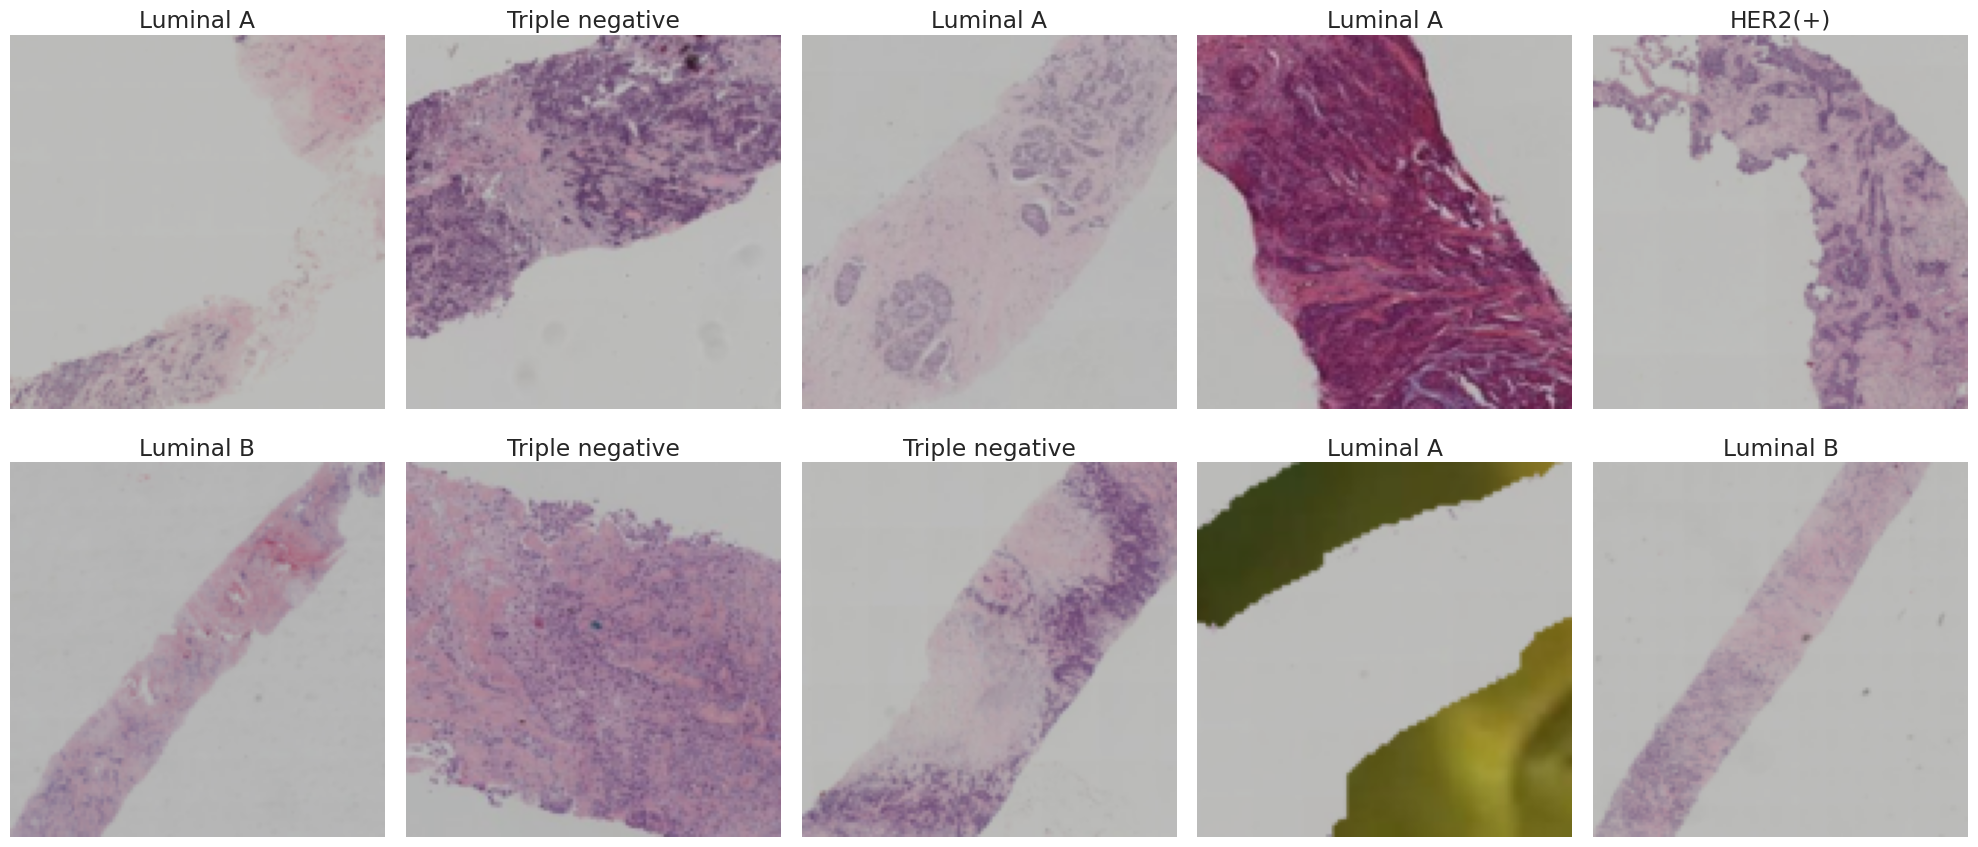

In [ ]:
show_samples(X_train_tensor, y_train_tensor,
        class_names=class_names,
        num_img=10,
        show_mask=False,
        inv_normalize=True)

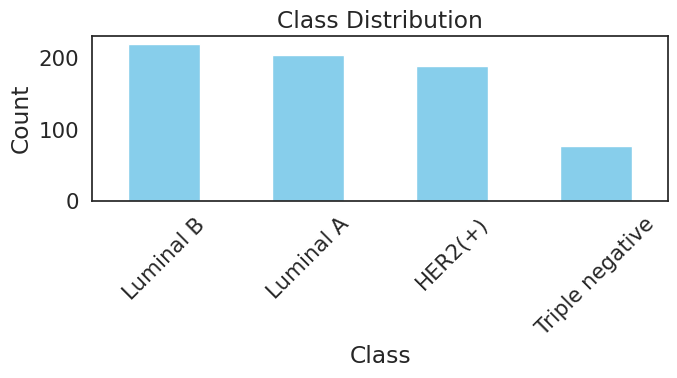

In [ ]:
labels_df['label'].value_counts().plot(
    kind='bar',
    figsize=(7, 4),
    color='skyblue'
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import umap
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

# ----------------------------
# CONFIGURATION
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

# ----------------------------
# Feature Extraction using ConvNeXt
# ----------------------------
print("Extracting features with ConvNeXt...")

model = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)
model = model.to(device).eval()

# Remove classifier head
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])

N = X_train_tensor.shape[0]
features_list = []

with torch.no_grad():
    for i in range(0, N, BATCH_SIZE):
        batch = X_train_tensor[i:i+BATCH_SIZE].to(device)
        feats = feature_extractor(batch).flatten(1)  # shape: (B, F)
        features_list.append(feats.cpu())
features = torch.cat(features_list, dim=0).cpu().numpy().astype(np.float32)
print(f"Features shape: {features.shape}")

Extracting features with ConvNeXt...
Features shape: (691, 1024)


Running UMAP...
UMAP embedding shape: (691, 2)


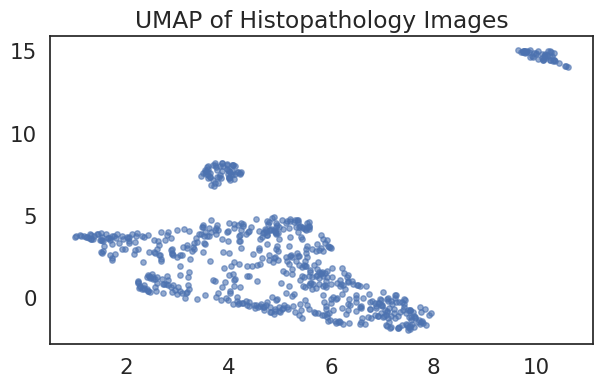

In [ ]:
# ----------------------------
# Dimensionality Reduction with UMAP
# ----------------------------
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(features)
print(f"UMAP embedding shape: {embedding.shape}")


# ----------------------------
# Plot UMAP with outliers highlighted
# ----------------------------
plt.figure(figsize=(7, 4))
plt.scatter(embedding[:, 0], embedding[:, 1], cmap="coolwarm", s=15, alpha=0.6)
plt.title("UMAP of Histopathology Images")
plt.show()



##  📄 **Data Preprocessing**

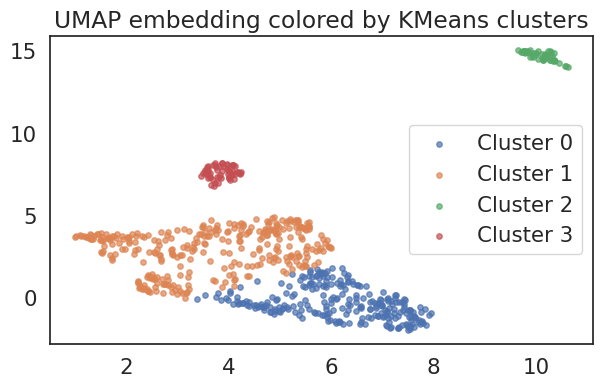

In [ ]:
from sklearn.cluster import KMeans

# Fit KMeans to UMAP embedding
n_clusters = 4  # there are 4 big clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embedding)

# Plot colored by cluster
plt.figure(figsize=(7,4))
for i in range(n_clusters):
    plt.scatter(embedding[cluster_labels==i,0], embedding[cluster_labels==i,1], label=f"Cluster {i}", s=15, alpha=0.7)
plt.title("UMAP embedding colored by KMeans clusters")
plt.legend()
plt.show()


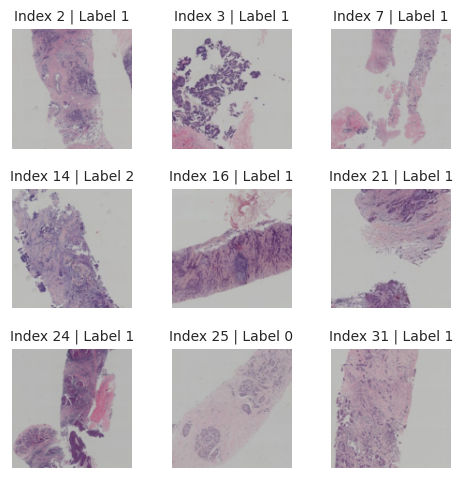

In [ ]:
outlier_indices = np.where(cluster_labels == 1)[0]

n_to_show = min(9, len(outlier_indices))
selected_indices = outlier_indices[:n_to_show]

# Display first images
fig, axes = plt.subplots(3, 3, figsize=(5, 5))
axes = axes.flatten()

for ax, idx in zip(axes, selected_indices):
    img_tensor, label = full_ds[idx]

    # Convert CHW -> HWC
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()

    # Optional: undo ImageNet normalization
    img_np = img_np * IMAGENET_STD + IMAGENET_MEAN
    img_np = np.clip(img_np, 0, 1)

    ax.imshow(img_np)
    ax.set_title(f"Index {idx} | Label {label}", fontsize=10)
    ax.axis("off")

# Hide empty subplots if fewer than 9 images
for j in range(n_to_show, 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
(outlier_indices)

array([  2,   3,   7,  14,  16,  21,  24,  25,  31,  32,  33,  34,  37,
        39,  40,  45,  49,  50,  54,  55,  57,  58,  59,  60,  61,  63,
        64,  65,  66,  67,  68,  69,  74,  75,  76,  78,  80,  81,  83,
        84,  87,  88,  91,  93,  96,  98,  99, 101, 103, 107, 109, 110,
       112, 114, 115, 117, 120, 121, 123, 124, 125, 128, 131, 135, 137,
       141, 142, 147, 151, 154, 160, 162, 164, 165, 166, 169, 170, 171,
       172, 176, 177, 182, 183, 185, 186, 188, 190, 192, 197, 199, 203,
       204, 205, 206, 207, 208, 210, 218, 225, 226, 227, 230, 231, 234,
       235, 236, 239, 242, 243, 244, 247, 249, 250, 252, 255, 258, 260,
       261, 262, 264, 265, 267, 270, 271, 272, 273, 276, 281, 283, 284,
       287, 288, 289, 291, 292, 294, 295, 297, 298, 299, 301, 302, 305,
       307, 309, 310, 311, 314, 316, 317, 320, 323, 324, 330, 331, 335,
       336, 337, 339, 341, 343, 345, 347, 349, 356, 357, 361, 362, 363,
       364, 365, 367, 369, 370, 373, 374, 378, 381, 382, 384, 39

In [ ]:
# Keep only rows NOT in outlier indices
filtered_df = labels_df.drop(index=outlier_indices).reset_index(drop=True)

print("Original size:", len(labels_df))
print("Filtered size:", len(filtered_df))
print("Removed:", len(outlier_indices), "outliers")


Original size: 691
Filtered size: 365
Removed: 326 outliers


In [ ]:
filtered_df.head(10)

,sample_index,label
0,img_0000.png,Triple negative
1,img_0001.png,Luminal B
2,img_0004.png,Luminal B
3,img_0005.png,HER2(+)
4,img_0006.png,Luminal A
5,img_0008.png,HER2(+)
6,img_0009.png,Luminal B
7,img_0010.png,Luminal B
8,img_0011.png,Luminal A
9,img_0012.png,Luminal A
